In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [9]:
def check_p_value_uniformity(K,layer, num_trials=1000):
    p_values = []


    for _ in range(num_trials):
        #X, y = make_blobs(n_samples=n, centers=real_K, cluster_std=1,random_state=42)
        X = np.random.normal(0, 1, size=(20, 10))
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=1, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs, cdf = model.merge_inference(node)
        p_values.append(p_value)

    p_values = np.array(p_values)

    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, color="blue", alpha=0.7, edgecolor="black")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    theoretical_quantiles = np.linspace(0, 1, num_trials)
    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', label="Empirical p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


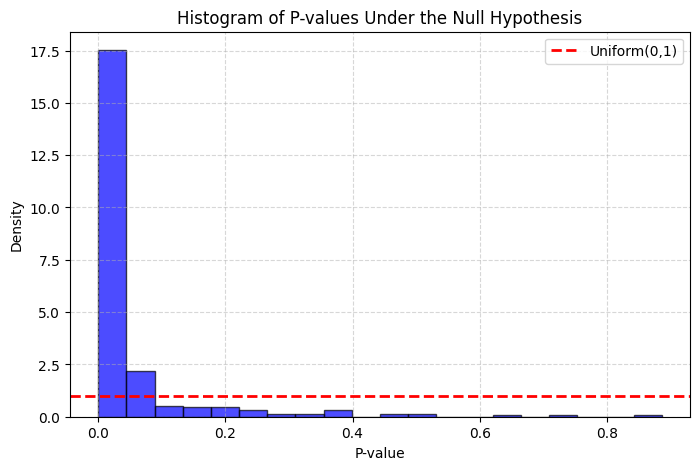

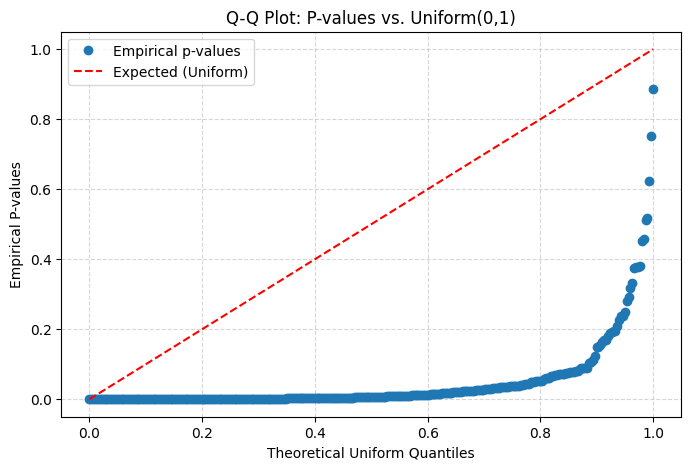

In [10]:
check_p_value_uniformity(3,0,300)

In [62]:
def plot_p_value(stat_grid, cdf, observed_target, p_value):
    observed_cdf_value = np.interp(observed_target, stat_grid, cdf)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(stat_grid, cdf, label="CDF", color="blue", lw=2)
    plt.axvline(observed_target, color='red', linestyle='dashed', lw=2, label="Observed Target")
    
    plt.fill_between(stat_grid, cdf, 1, where=(stat_grid >= observed_target), color='red', alpha=0.3, label="p-value region")

    plt.text(observed_target, 0.05, f"Observed Target = {observed_target:.3f}", color='red', fontsize=12, rotation=90, verticalalignment='bottom')
    plt.text(stat_grid[-1]*0.85, 0.8, f"p-value = {p_value:.4f}", color='red', fontsize=14, bbox=dict(facecolor='white', edgecolor='red'))

    plt.xlabel(r"$X$ (Test Statistic)")
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title("Visualization of p-value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
  
    plt.show()

In [63]:
grid = np.linspace(0.00001, 15, num=1000)

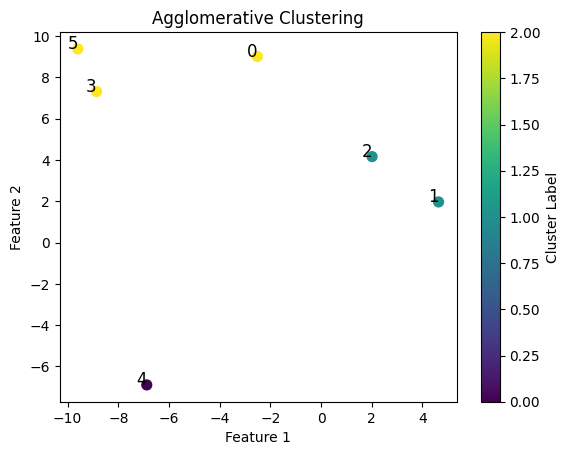

In [8]:
X, y = make_blobs(n_samples=6, centers=6, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [65]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

level:  1


np.float64(0.65560065001003)

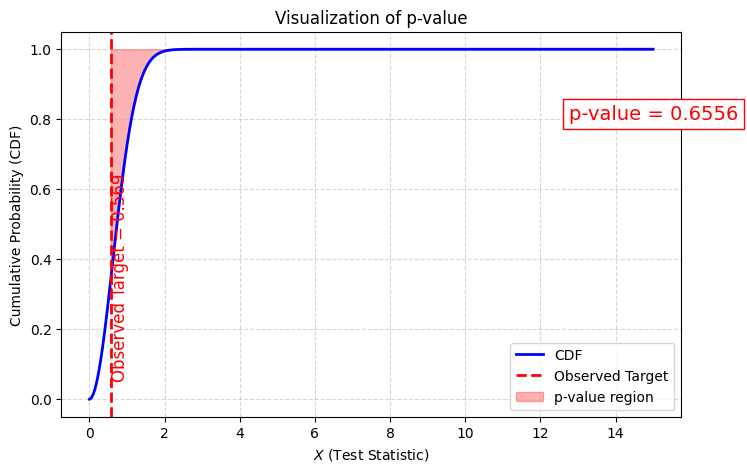

In [66]:
plot_p_value(grid, cdf, obs, pvalue)

In [67]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

level:  3
level:  2
level:  1


np.float64(1.3172555579643586e-07)

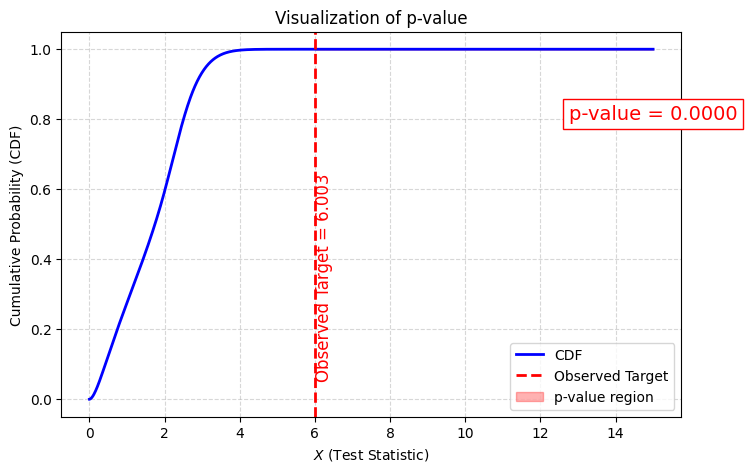

In [68]:
plot_p_value(grid, cdf, obs, pvalue)

In [69]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[2]), ClusterNode(points=[5])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5])]
Merge: (ClusterNode(points=[0]), ClusterNode(points=[1])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[2, 5])]
Merge: (ClusterNode(points=[4]), ClusterNode(points=[0, 1])) -> Clusters: [ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[2, 5]), ClusterNode(points=[0, 1])]


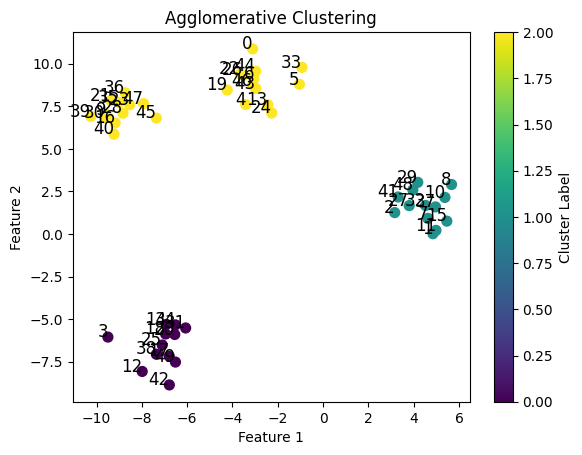

In [70]:
X, y = make_blobs(n_samples=50, centers=4, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [71]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)

level:  1


In [72]:
pvalue

np.float64(0.07144954978263507)

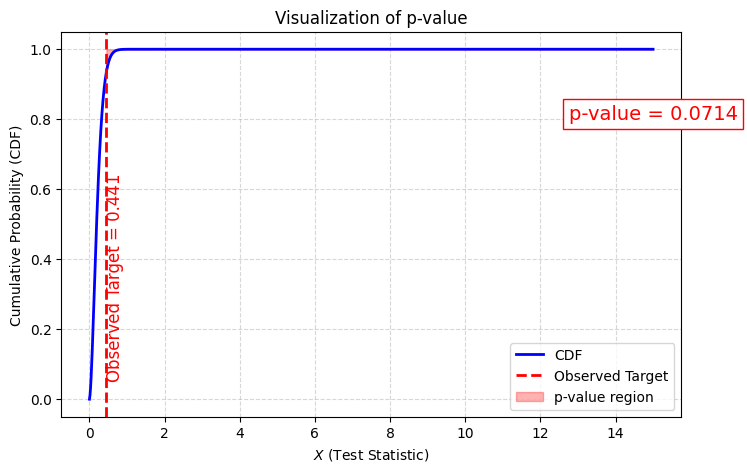

In [73]:
plot_p_value(grid, cdf, obs, pvalue)

In [74]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

level:  47
level:  46
level:  45
level:  44
level:  43
level:  42
level:  41
level:  40
level:  39
level:  38
level:  37
level:  36
level:  35
level:  34
level:  33
level:  32
level:  31
level:  30
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1


np.float64(0.0)

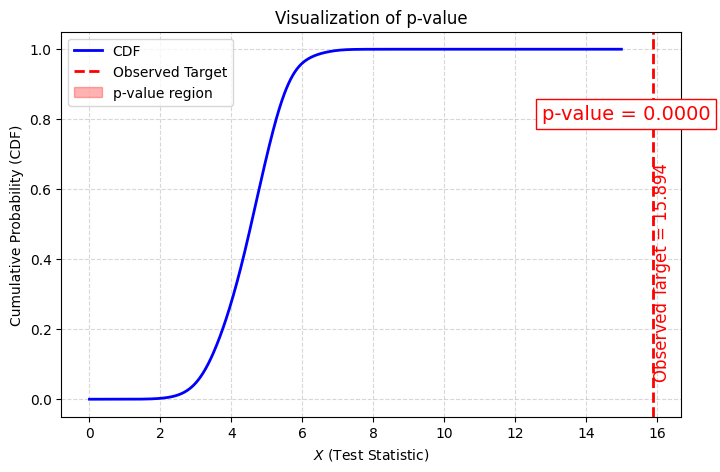

In [75]:
plot_p_value(grid, cdf, obs, pvalue)

In [10]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent

In [11]:
node

ClusterNode(points=[57, 85])

In [12]:
model.merge_inference(node)

level:  1


(np.float64(0.7243510292052009), np.float64(0.04029604995739534))

In [17]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=10
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

In [18]:
model._approx_log_reference(node, stat_grid, nuisance,dir,
                              contrast, sd=1, sd_rand=1)

current step: 2
level:  2
selection probability: -106.67641231597372
selection probability: -105.28112129576039
selection probability: -105.68990252850199
selection probability: -107.08367415764951
selection probability: -108.49547987392361
selection probability: -109.94976685706206
selection probability: -111.39801081608675
selection probability: -112.89320955859876
selection probability: -114.38468460893637
selection probability: -115.9450543060666
selection probability: -117.46622835161907
selection probability: -119.03938734575786
selection probability: -121.12623251988407
selection probability: -122.2700295396753
selection probability: -123.91625778987873
selection probability: -125.58713991568584
selection probability: -127.29683119301262
selection probability: -129.0157525089926
selection probability: -130.7677106387091
selection probability: -132.54617794760634
selection probability: -134.36748852753954
selection probability: -136.1767345126318
selection probability: -138.03228

array([-218.93845354, -217.5413656 , -218.03333582, -219.3377064 ,
       -220.75833969, -222.18477742, -223.63207647, -225.09934433,
       -226.59764478, -228.36468832, -229.68015804, -231.17604936,
       -233.24558437, -234.37267657, -236.62117894, -237.63405627,
       -239.32237427, -241.01995812, -242.76467537, -244.53591447,
       -246.30570263, -248.08939906, -249.95543255, -252.0533956 ,
       -253.71881948, -255.58385077, -257.58454429, -259.51259805,
       -261.59178114, -263.50163417, -265.66706628, -267.62836666,
       -269.7428615 , -271.89045362, -274.05889774, -276.25953254,
       -278.4833381 , -280.7438433 , -283.07923153, -285.36538623,
       -287.94189405, -290.11606655, -292.54643147, -294.99670651,
       -297.78103763, -299.99704935, -302.54993732, -305.21074567,
       -307.78742419, -310.41777433, -313.09539311, -315.80996941,
       -318.55186232, -321.36742914, -324.16092759, -327.0359185 ,
       -329.90218871, -332.83173738, -335.78765091, -338.77839

In [19]:
model.existing_clusters_log.keys()

dict_keys([(ClusterNode(points=[25]), ClusterNode(points=[49])), (ClusterNode(points=[32]), ClusterNode(points=[37])), (ClusterNode(points=[22]), ClusterNode(points=[26])), (ClusterNode(points=[9]), ClusterNode(points=[28])), (ClusterNode(points=[6]), ClusterNode(points=[44])), (ClusterNode(points=[43]), ClusterNode(points=[46])), (ClusterNode(points=[41]), ClusterNode(points=[48])), (ClusterNode(points=[1]), ClusterNode(points=[11])), (ClusterNode(points=[18]), ClusterNode(points=[34])), (ClusterNode(points=[20]), ClusterNode(points=[18, 34])), (ClusterNode(points=[12]), ClusterNode(points=[38])), (ClusterNode(points=[4]), ClusterNode(points=[43, 46])), (ClusterNode(points=[16]), ClusterNode(points=[23])), (ClusterNode(points=[40]), ClusterNode(points=[16, 23])), (ClusterNode(points=[10]), ClusterNode(points=[32, 37])), (ClusterNode(points=[19]), ClusterNode(points=[4, 43, 46])), (ClusterNode(points=[9, 28]), ClusterNode(points=[40, 16, 23])), (ClusterNode(points=[2]), ClusterNode(poi

In [9]:
nu

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [16]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 10.32707171908997
(ClusterNode(points=[0]), ClusterNode(points=[2])): 9.68422689887704
(ClusterNode(points=[0]), ClusterNode(points=[3])): 9.060078890465663
(ClusterNode(points=[0]), ClusterNode(points=[4])): 2.082076454428245
(ClusterNode(points=[0]), ClusterNode(points=[5])): 0.5893752919975326
(ClusterNode(points=[0]), ClusterNode(points=[6])): 11.170588757791954
(ClusterNode(points=[0]), ClusterNode(points=[7])): 15.986331082971805
(ClusterNode(points=[0]), ClusterNode(points=[8])): 2.5568131803081324
(ClusterNode(points=[0]), ClusterNode(points=[9])): 18.544392609919342
(ClusterNode(points=[0]), ClusterNode(points=[10])): 10.88408495962521
(ClusterNode(points=[0]), ClusterNode(points=[11])): 17.198109537858937
(ClusterNode(points=[0]), ClusterNode(points=[12])): 10.548580349948585
(ClusterNode(points=[0]), ClusterNode(points=[13])): 12.342766358092684
(ClusterNode(points=[0]), ClusterNode(points=[14])): 0.4380892041

In [23]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[16]), ClusterNode(points=[30])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[10]), ClusterNode(points=[11]), ClusterNode(points=[12]), ClusterNode(points=[13]), ClusterNode(points=[14]), ClusterNode(points=[15]), ClusterNode(points=[16]), ClusterNode(points=[17]), ClusterNode(points=[18]), ClusterNode(points=[19]), ClusterNode(points=[20]), ClusterNode(points=[21]), ClusterNode(points=[22]), ClusterNode(points=[23]), ClusterNode(points=[24]), ClusterNode(points=[25]), ClusterNode(points=[26]), ClusterNode(points=[27]), ClusterNode(points=[28]), ClusterNode(points=[29]), ClusterNode(points=[30]), ClusterNode(points=[31]), ClusterNode(points=[32]), ClusterNode(points=[33]), ClusterNode(points=[34]), Cl

In [12]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")
    break


Randomization Log:
1: {(ClusterNode(points=[0]), ClusterNode(points=[1])): -0.15532730203639716, (ClusterNode(points=[0]), ClusterNode(points=[2])): 0.37716050833360587, (ClusterNode(points=[0]), ClusterNode(points=[3])): -1.4925275773298345, (ClusterNode(points=[0]), ClusterNode(points=[4])): -0.5971903486356805, (ClusterNode(points=[0]), ClusterNode(points=[5])): -1.038768012151307, (ClusterNode(points=[0]), ClusterNode(points=[6])): 1.2714791923247728, (ClusterNode(points=[0]), ClusterNode(points=[7])): 0.11916127612252046, (ClusterNode(points=[0]), ClusterNode(points=[8])): -0.5272357288201084, (ClusterNode(points=[0]), ClusterNode(points=[9])): -2.437825273820015, (ClusterNode(points=[0]), ClusterNode(points=[10])): -0.04496611298143697, (ClusterNode(points=[0]), ClusterNode(points=[11])): 1.1995318418163068, (ClusterNode(points=[0]), ClusterNode(points=[12])): 0.3352126700535773, (ClusterNode(points=[0]), ClusterNode(points=[13])): -1.5789817614063508, (ClusterNode(points=[0]), C

In [13]:
np.shape(nuisance)

(50, 2)

In [14]:
np.shape(nu)

(50,)